# 12. local↔Public 캘리브레이션 랩

> 선행 노트북: [11_promotion_scoreboard.ipynb](11_promotion_scoreboard.ipynb)
> 선행 설계서: [05-feature-set-promotion.md](../docs/design/05-feature-set-promotion.md),
> [06-preprocessing-guardrails.md](../docs/design/06-preprocessing-guardrails.md)

노트북 11은 제출 후보 S1·S2를 만들고 ledger의 절반을 비워 둔 채 끝났다.
사람이 제출 버튼을 눌러 Public 점수 두 개가 돌아왔고, 이 노트북이 그 두 칸을 채운다.

**연구 질문**

> local holdout에서 잰 개선분 +0.014743이 Public에서도 같은 크기로 나타나는가?
> 어긋난다면, 그 어긋남을 무엇으로 설명해야 하는가?

**이 노트북이 앞선 노트북과 다른 점**

노트북 06~11은 전부 우리가 점수를 직접 계산할 수 있는 구간을 다뤘다. 여기서는 처음으로
**우리가 계산할 수 없는 점수**를 다룬다. Public 점수는 리더보드만 알고 있고, 우리에게
주어지는 것은 소수점 10자리 숫자 두 개뿐이다. 숫자 두 개로 기울기를 말하려면 그 두
숫자가 얼마나 흔들리는 값인지부터 알아야 한다.

대회 안내문의 한 문장이 이 노트북의 방법을 결정한다.

> Public Score : 전체 평가 데이터 중 **사전 샘플링된 40%**

즉 Public은 전수 채점이 아니다. 40% 표본에서 나온 값이므로 **표본 분산**을 갖는다.
설계서 06의 5.3절이 적어 둔 세 가지 구조적 이유를 따지기 전에, 이 분산부터 재야 한다.
그러지 않으면 잡음을 원인으로 착각하게 된다.

In [1]:
from pathlib import Path
import hashlib
import json
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import font_manager


def resolveProjectRoot():
  """worktree/일반 체크아웃 어디서 실행하든 src를 찾는다."""
  here = Path.cwd().resolve()
  for candidate in [here, *here.parents]:
    if (candidate / "src" / "baram").is_dir():
      return candidate
  raise RuntimeError("src/baram을 찾지 못했습니다")


def resolveOfficialDataDir(projectRoot):
  for candidate in [projectRoot, *projectRoot.parents]:
    dataDir = candidate / "data" / "raw" / "open"
    if (dataDir / "train" / "train_labels.csv").is_file():
      return dataDir
  raise RuntimeError("공식 데이터 디렉터리를 찾지 못했습니다")


def resolveArtifactRoot(projectRoot):
  """outputs/는 gitignore 대상이라 worktree에는 없다. run registry가 있는 곳이 정본이다."""
  for candidate in [projectRoot, *projectRoot.parents]:
    outputs = candidate / "outputs"
    if (outputs / "run_registry.csv").is_file():
      return outputs
  raise RuntimeError("run_registry.csv를 가진 outputs/를 찾지 못했습니다")


projectRoot = resolveProjectRoot()
if str(projectRoot / "src") not in sys.path:
  sys.path.insert(0, str(projectRoot / "src"))
dataDir = resolveOfficialDataDir(projectRoot)
outputRoot = resolveArtifactRoot(projectRoot)

sns.set_theme(style="whitegrid")
fontCandidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "DejaVu Sans"]
availableFonts = {font.name for font in font_manager.fontManager.ttflist}
selectedFont = next((font for font in fontCandidates if font in availableFonts), "DejaVu Sans")
plt.rcParams["font.family"] = selectedFont
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")

print(f"project root : {projectRoot.name}")
print(f"official data: {dataDir}")
print(f"outputs      : {outputRoot}")
print(f"한글 폰트    : {selectedFont}")

project root : baram-submission-ledger-slope-d665d7
official data: C:\Users\kik32\workspace\Dacon\baram-2026-wind-power-forecasting\data\raw\open
outputs      : C:\Users\kik32\workspace\Dacon\baram-2026-wind-power-forecasting\outputs
한글 폰트    : Malgun Gothic


`outputs/`는 `.gitignore` 대상이라 worktree에는 존재하지 않는다. 그래서 09~11이 쓰던
탐색 규약에 `resolveArtifactRoot()`를 하나 더했다 — `run_registry.csv`를 가진 디렉터리를
부모 방향으로 찾아 올라간다. 원자료를 찾는 방식과 같은 규약이며, 이 덕분에 노트북을
worktree에서 실행해도 ledger 정본을 갱신한다.

---

## 1. 대회 규칙 중 이 분석의 방법을 바꾸는 항목

규칙을 상수로 박아 두고 시작한다. 문서에만 적어 두면 코드가 규칙과 어긋나도 조용하다.

In [2]:
# 대회 안내문에서 이번 분석의 방법을 직접 바꾸는 항목만 상수로 옮긴다.
PUBLIC_SAMPLE_FRACTION = 0.40   # Public Score = 전체 평가 데이터 중 사전 샘플링된 40%
PRIVATE_SAMPLE_FRACTION = 0.60  # Private Score = 나머지 60%. 최종 1차 평가는 이쪽 100%
DAILY_SUBMISSION_LIMIT = 5      # 1일 최대 제출 횟수
EVALUATION_CAPACITY_RATIO = 0.10  # 실제 발전량이 설비용량의 10% 이상인 시간대만 평가
FICR_UNIT_PRICE = [(0.06, 4.0), (0.08, 3.0)]  # 오차율 6% 이하 4원, 8% 이하 3원, 초과 0원

ruleImpact = pd.DataFrame(
  [
    ("Public은 40% 표본", "두 점의 차이에 표본 분산이 섞인다", "5절에서 부트스트랩으로 크기를 잰다"),
    ("Private은 나머지 60%", "우리가 보는 점수는 최종 점수가 아니다", "기울기를 Private 예측으로 쓰지 않는다"),
    ("순위 최고 파일이 자동 선택", "Public 최고점이 최종 채점 대상이 된다", "Decision Box ⑰에서 선택 정책을 정한다"),
    ("1일 5회", "오늘 2회 사용, 3회 남음", "남은 슬롯을 잡음 확인에 낭비하지 않는다"),
    ("평가 대상은 용량 10% 이상 행", "8,760행 전체가 아니다", "부트스트랩도 같은 필터를 적용한다"),
    ("train/inference 코드 분리 제출", "2차 평가 산출물 요건", "이미 CLI가 분리돼 있어 추가 작업 없음"),
  ],
  columns=["규칙", "이 분석에 주는 영향", "대응"],
)
display(ruleImpact)

,규칙,이 분석에 주는 영향,대응
0,Public은 40% 표본,두 점의 차이에 표본 분산이 섞인다,5절에서 부트스트랩으로 크기를 잰다
1,Private은 나머지 60%,우리가 보는 점수는 최종 점수가 아니다,기울기를 Private 예측으로 쓰지 않는다
2,순위 최고 파일이 자동 선택,Public 최고점이 최종 채점 대상이 된다,Decision Box ⑰에서 선택 정책을 정한다
3,1일 5회,"오늘 2회 사용, 3회 남음",남은 슬롯을 잡음 확인에 낭비하지 않는다
4,평가 대상은 용량 10% 이상 행,"8,760행 전체가 아니다",부트스트랩도 같은 필터를 적용한다
5,train/inference 코드 분리 제출,2차 평가 산출물 요건,이미 CLI가 분리돼 있어 추가 작업 없음


### 1-1. 40%라는 숫자가 방법을 바꾼다

여섯 항목 중 첫 번째가 결정적이다. Public이 전수 채점이었다면 두 점의 차이는
곧 실력 차이였을 것이다. 40% 표본이라면 같은 모델이라도 어떤 40%가 뽑혔느냐에 따라
점수가 달라진다. **그 흔들림보다 작은 차이는 해석하면 안 된다.**

세 번째 항목도 기록해 둔다. 대회 안내문은 "파일 제출 시마다 순위가 가장 높은 파일이
자동으로 선택됨"이라고 명시한다. Public 기준으로 자동 선택되는데 최종 채점은 Private이므로,
이 자동 선택을 그대로 두는 것은 **Public에 과적합된 파일을 최종 제출로 고정하는 것**과 같다.

---

## 2. Public 점수 반입

제출 화면에서 옮겨 적은 값이다. 옮겨 적는 과정에서 틀릴 수 있으므로 공식 산식의
항등식으로 검증한다.

In [3]:
# DACON 제출 화면(2026-07-27)에서 옮겨 적은 값. 화면 표기 그대로 소수점 10자리까지.
PUBLIC_RESULTS = {
  "S1": {
    "dacon_submission_id": "1502789",
    "submitted_at_kst": "2026-07-27 11:11:10",
    "file": "s1_official_mean.csv",
    "feature_set": "official_mean",
    "total": 0.5883029124,
    "one_minus_nmae": 0.8644254969,
    "ficr": 0.3121803279,
    "selected": False,
  },
  "S2": {
    "dacon_submission_id": "1502791",
    "submitted_at_kst": "2026-07-27 11:12:23",
    "file": "s2_spatial_idw2_all_group.csv",
    "feature_set": "spatial_idw2_all_group",
    "total": 0.6063740475,
    "one_minus_nmae": 0.869898839,
    "ficr": 0.342849256,
    "selected": True,
  },
}

# total = 0.5 * (1-NMAE) + 0.5 * FICR 가 성립해야 한다. 전사 오류를 여기서 잡는다.
identityRows = []
for slot, record in PUBLIC_RESULTS.items():
  rebuilt = 0.5 * record["one_minus_nmae"] + 0.5 * record["ficr"]
  identityRows.append(
    {
      "slot": slot,
      "제출 ID": record["dacon_submission_id"],
      "화면 total": record["total"],
      "산식 재계산": rebuilt,
      "절대 차이": abs(rebuilt - record["total"]),
      "판정": "일치" if abs(rebuilt - record["total"]) < 5e-11 else "불일치",
    }
  )
identityFrame = pd.DataFrame(identityRows).set_index("slot")
transcriptionOk = bool((identityFrame["판정"] == "일치").all())
print(f"제출 화면 값이 공식 산식 항등식을 만족하는가 : {transcriptionOk}")
with pd.option_context("display.float_format", lambda value: f"{value:.12g}"):
  display(identityFrame)

제출 화면 값이 공식 산식 항등식을 만족하는가 : True


,제출 ID,화면 total,산식 재계산,절대 차이,판정
slot,,,,,
S1,1502789,0.5883029124,0.5883029124,0,일치
S2,1502791,0.6063740475,0.6063740475,0,일치


### 2-1. 전사 검증 통과

`total = 0.5 x (1-NMAE) + 0.5 x FICR`가 두 행 모두에서 성립한다. 화면에서 숫자를 옮기며
자리를 밀어 쓰는 실수는 이 검증에서 걸린다.

Public 점수가 두 지표로 쪼개져 나온다는 점이 중요하다. 총점만 있었다면 "올랐다"까지만
말할 수 있었겠지만, 1-NMAE와 FICR이 따로 있으므로 **개선분이 어느 쪽에서 왔는지**를
local과 같은 방식으로 분해할 수 있다.

---

## 3. local 기준값 재계산

기울기를 계산하려면 local 쪽 숫자도 필요하다. ledger에 적힌 6자리 반올림값이 아니라
전체 정밀도가 필요하므로(Decision Box ⑪), 노트북 11과 같은 조건으로 다시 계산한다.

In [4]:
from baram.baseline import OFFICIAL_RF_PARAMS
from baram.feature_config import get_feature_set
from baram.feature_pipeline import build_feature_pipeline
from baram.features.turbine_metadata import load_turbine_locations
from baram.metrics import CAPACITY_KWH, TARGET_COLS, metric


def readOfficial(relativePath):
  return pd.read_csv(dataDir / relativePath, encoding="utf-8-sig")


trainLabels = readOfficial("train/train_labels.csv")
trainLabels["kst_dtm"] = pd.to_datetime(trainLabels["kst_dtm"])
ldapsTrain = readOfficial("train/ldaps_train.csv")
gfsTrain = readOfficial("train/gfs_train.csv")
turbines = load_turbine_locations(dataDir / "info.xlsx")

HOLDOUT_YEAR = 2024
labelYear = trainLabels["kst_dtm"].dt.year
modelTrainMask = labelYear < HOLDOUT_YEAR
holdoutMask = labelYear == HOLDOUT_YEAR


def yearSlice(frame, comparison):
  forecast = pd.to_datetime(frame["forecast_kst_dtm"], errors="raise")
  keep = forecast.dt.year < HOLDOUT_YEAR if comparison == "lt" else forecast.dt.year == HOLDOUT_YEAR
  return frame[keep]


splitFrames = {
  "train_ldaps": yearSlice(ldapsTrain, "lt"),
  "train_gfs": yearSlice(gfsTrain, "lt"),
  "holdout_ldaps": yearSlice(ldapsTrain, "eq"),
  "holdout_gfs": yearSlice(gfsTrain, "eq"),
}

# 실제값은 원본을 그대로 유지한다. clip은 예측에만 적용한다.
holdoutActual = trainLabels.loc[holdoutMask, TARGET_COLS].copy(deep=True)
actualFingerprint = hashlib.sha256(
  pd.util.hash_pandas_object(holdoutActual, index=True).to_numpy().tobytes()
).hexdigest()

print(f"학습 행(2022~2023) : {int(modelTrainMask.sum())}")
print(f"holdout 행(2024)   : {int(holdoutMask.sum())}")
print(f"경계 행(2025)      : {int((labelYear > HOLDOUT_YEAR).sum())}  -> 어느 쪽에도 넣지 않음")
print(f"holdout 실제값 SHA-256 : {actualFingerprint[:16]}...")

학습 행(2022~2023) : 17519
holdout 행(2024)   : 8784
경계 행(2025)      : 1  -> 어느 쪽에도 넣지 않음
holdout 실제값 SHA-256 : b26ba28bb53d47c6...


분할은 노트북 08·11과 같다. 2025-01-01 00:00 경계 행 1건은 라벨이 01:00 시작 규약이라
생기는 것으로, 학습에도 holdout에도 넣지 않는다.

아래에서 두 프리셋의 holdout 예측을 다시 만든다. 예측 자체가 필요하다 — 5절과 6절에서
점수뿐 아니라 **행 단위 오차율**을 써야 하기 때문이다.

In [5]:
SLOTS = {"S1": "official_mean", "S2": "spatial_idw2_all_group"}
# 노트북 08 출력에 남은 전체 정밀도 값. 재현 판정은 6자리 표기가 아니라 이 값에 건다.
LOCAL_REFERENCE = {
  "S1": 0.5777425681025163,
  "S2": 0.5924854297224146,
}
G3_TOLERANCE = 1e-9


def scoreFeatureSet(featureSetName):
  """노트북 08·11과 동일한 조건으로 2024 holdout 예측과 점수를 만든다."""
  from sklearn.ensemble import RandomForestRegressor
  from sklearn.impute import SimpleImputer

  config = get_feature_set(featureSetName)
  pipeline = build_feature_pipeline(
    config,
    train_time_index=trainLabels.loc[modelTrainMask, "kst_dtm"],
    test_time_index=trainLabels.loc[holdoutMask, "kst_dtm"],
    train_ldaps=splitFrames["train_ldaps"],
    train_gfs=splitFrames["train_gfs"],
    test_ldaps=splitFrames["holdout_ldaps"],
    test_gfs=splitFrames["holdout_gfs"],
    turbine_locations=turbines if config.uses_spatial else None,
  )
  imputer = SimpleImputer(strategy="median")
  trainImputed = pd.DataFrame(
    imputer.fit_transform(pipeline.train_matrix),
    columns=pipeline.feature_columns,
    index=pipeline.train_matrix.index,
  )
  holdoutImputed = pd.DataFrame(
    imputer.transform(pipeline.test_matrix),
    columns=pipeline.feature_columns,
    index=pipeline.test_matrix.index,
  )
  predictions = pd.DataFrame(index=holdoutActual.index)
  trainSubset = trainLabels.loc[modelTrainMask]
  for target in TARGET_COLS:
    targetColumns = list(pipeline.target_feature_columns[target])
    labels = trainSubset[target]
    nonNull = labels.notna().to_numpy()
    model = RandomForestRegressor(**dict(OFFICIAL_RF_PARAMS))
    model.fit(trainImputed.loc[nonNull, targetColumns], labels.to_numpy()[nonNull])
    predictions[target] = np.clip(
      model.predict(holdoutImputed[targetColumns]), 0, CAPACITY_KWH[target]
    )
  return predictions


holdoutPredictions = {}
localScores = {}
for slot, featureSetName in SLOTS.items():
  started = time.perf_counter()
  holdoutPredictions[slot] = scoreFeatureSet(featureSetName)
  total, oneMinusNmae, ficr = metric(holdoutActual, holdoutPredictions[slot])
  localScores[slot] = {"total": total, "one_minus_nmae": oneMinusNmae, "ficr": ficr}
  difference = abs(total - LOCAL_REFERENCE[slot])
  print(
    f"{slot} {featureSetName:24s} total={total!r}  "
    f"노트북 08 대비 {difference:.3e}  {'통과' if difference <= G3_TOLERANCE else '실패'}  "
    f"({time.perf_counter() - started:.1f}s)"
  )

reproductionOk = all(
  abs(localScores[slot]["total"] - LOCAL_REFERENCE[slot]) <= G3_TOLERANCE for slot in SLOTS
)
print(f"\n재현 게이트({G3_TOLERANCE:.0e}) 통과 : {reproductionOk}")
print(
  "holdout 실제값 SHA-256 불변 :",
  hashlib.sha256(
    pd.util.hash_pandas_object(holdoutActual, index=True).to_numpy().tobytes()
  ).hexdigest() == actualFingerprint,
)

S1 official_mean            total=0.5777425681025163  노트북 08 대비 0.000e+00  통과  (2.7s)


S2 spatial_idw2_all_group   total=0.5924854297224146  노트북 08 대비 0.000e+00  통과  (14.6s)

재현 게이트(1e-09) 통과 : True
holdout 실제값 SHA-256 불변 : True


### 3-1. 재현 게이트 통과

두 프리셋 모두 노트북 08의 전체 정밀도 값과 **절대 차이 0.0**으로 일치했다.
여기서 확인된 부수 사실이 하나 있다 — 이 실행 환경의 pandas·scikit-learn 버전이
`requirements-ci.txt`의 고정 버전과 다른데도 점수가 흔들리지 않았다. 다만 이는
같은 환경에서의 **일관성**이지 버전 간 독립 검증은 아니므로, 고정 버전 승격 판단의
근거로는 쓰지 않는다.

---

## 4. 기울기 — 두 점을 잇는다

이제 local 두 점과 Public 두 점이 있다. 지표별로 나란히 놓는다.

In [6]:
comparisonRows = []
for slot in SLOTS:
  for key, label in [("total", "total"), ("one_minus_nmae", "1-NMAE"), ("ficr", "FICR")]:
    comparisonRows.append(
      {
        "slot": slot,
        "지표": label,
        "local": localScores[slot][key],
        "Public": PUBLIC_RESULTS[slot][key],
        "Public - local": PUBLIC_RESULTS[slot][key] - localScores[slot][key],
      }
    )
comparisonFrame = pd.DataFrame(comparisonRows).set_index(["지표", "slot"]).sort_index()

slopeRows = []
for key, label in [("total", "total"), ("one_minus_nmae", "1-NMAE"), ("ficr", "FICR")]:
  deltaLocal = localScores["S2"][key] - localScores["S1"][key]
  deltaPublic = PUBLIC_RESULTS["S2"][key] - PUBLIC_RESULTS["S1"][key]
  slopeRows.append(
    {
      "지표": label,
      "Δ local": deltaLocal,
      "Δ Public": deltaPublic,
      "기울기": deltaPublic / deltaLocal,
      "수준 이동 S1": PUBLIC_RESULTS["S1"][key] - localScores["S1"][key],
      "수준 이동 S2": PUBLIC_RESULTS["S2"][key] - localScores["S2"][key],
    }
  )
slopeFrame = pd.DataFrame(slopeRows).set_index("지표")

deltaLocalTotal = float(slopeFrame.loc["total", "Δ local"])
deltaPublicTotal = float(slopeFrame.loc["total", "Δ Public"])
slopeTotal = float(slopeFrame.loc["total", "기울기"])

display(comparisonFrame)
with pd.option_context("display.float_format", lambda value: f"{value:+.9f}"):
  display(slopeFrame)
print(f"총점 기울기 점추정 : ΔPublic {deltaPublicTotal:+.9f} / Δlocal {deltaLocalTotal:+.9f} = {slopeTotal:.4f}")

local   Public  Public - local
지표     slot                                  
1-NMAE S1   0.863317 0.864425        0.001108
       S2   0.869565 0.869899        0.000334
FICR   S1   0.292168 0.312180        0.020012
       S2   0.315406 0.342849        0.027443
total  S1   0.577743 0.588303        0.010560
       S2   0.592485 0.606374        0.013889

,Δ local,Δ Public,기울기,수준 이동 S1,수준 이동 S2
지표,,,,,
total,+0.014742862,+0.018071135,+1.225754916,+0.010560344,+0.013888618
1-NMAE,+0.006247844,+0.005473342,+0.876036930,+0.001108493,+0.000333991
FICR,+0.023237879,+0.030668928,+1.319781716,+0.020012195,+0.027443244


총점 기울기 점추정 : ΔPublic +0.018071135 / Δlocal +0.014742862 = 1.2258


숫자만으로는 방향이 잘 안 잡힌다. 두 점을 좌표에 올린다.

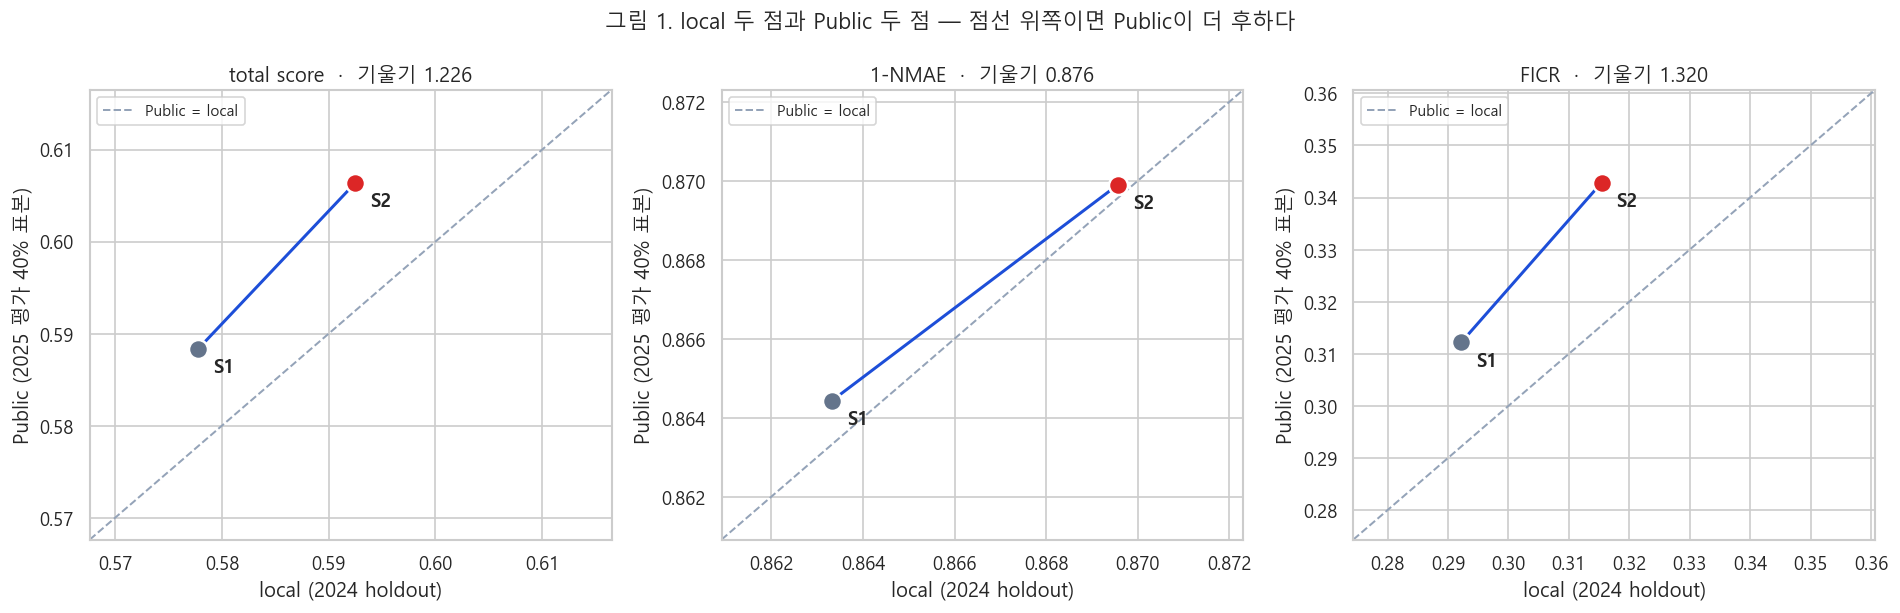

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
panelSpec = [("total", "total score"), ("one_minus_nmae", "1-NMAE"), ("ficr", "FICR")]
slotColor = {"S1": "#64748b", "S2": "#dc2626"}

for axis, (key, label) in zip(axes, panelSpec):
  xs = [localScores[slot][key] for slot in ["S1", "S2"]]
  ys = [PUBLIC_RESULTS[slot][key] for slot in ["S1", "S2"]]
  span = [min(xs + ys), max(xs + ys)]
  pad = (span[1] - span[0]) * 0.35 + 1e-4
  low, high = span[0] - pad, span[1] + pad

  axis.plot([low, high], [low, high], linestyle="--", color="#94a3b8", linewidth=1.2, label="Public = local")
  axis.plot(xs, ys, color="#1d4ed8", linewidth=1.8, zorder=2)
  for slot, x, y in zip(["S1", "S2"], xs, ys):
    axis.scatter([x], [y], s=130, color=slotColor[slot], zorder=3, edgecolor="white", linewidth=1.5)
    axis.annotate(slot, (x, y), textcoords="offset points", xytext=(9, -14), fontsize=11, fontweight="bold")

  slope = float(slopeFrame.loc[label if key != "total" else "total", "기울기"])
  axis.set_title(f"{label}  ·  기울기 {slope:.3f}", fontsize=12)
  axis.set_xlabel("local (2024 holdout)")
  axis.set_ylabel("Public (2025 평가 40% 표본)")
  axis.set_xlim(low, high)
  axis.set_ylim(low, high)
  axis.legend(loc="upper left", fontsize=9)

fig.suptitle("그림 1. local 두 점과 Public 두 점 — 점선 위쪽이면 Public이 더 후하다", fontsize=13)
fig.tight_layout()
plt.show()

### 4-1. 두 가지가 동시에 일어났다

그림 1에서 읽을 것은 두 가지다.

1. **두 점이 모두 점선 위에 있다.** Public이 local보다 높다. 이것은 기울기가 아니라
   **수준 이동**이다.
2. **total 패널의 선이 점선보다 가파르다.** 기울기 1.226. 다만 1-NMAE 패널은 오히려
   완만하다(0.876).

수준 이동과 기울기를 섞어 읽으면 안 된다. 지표별로 분해한다.

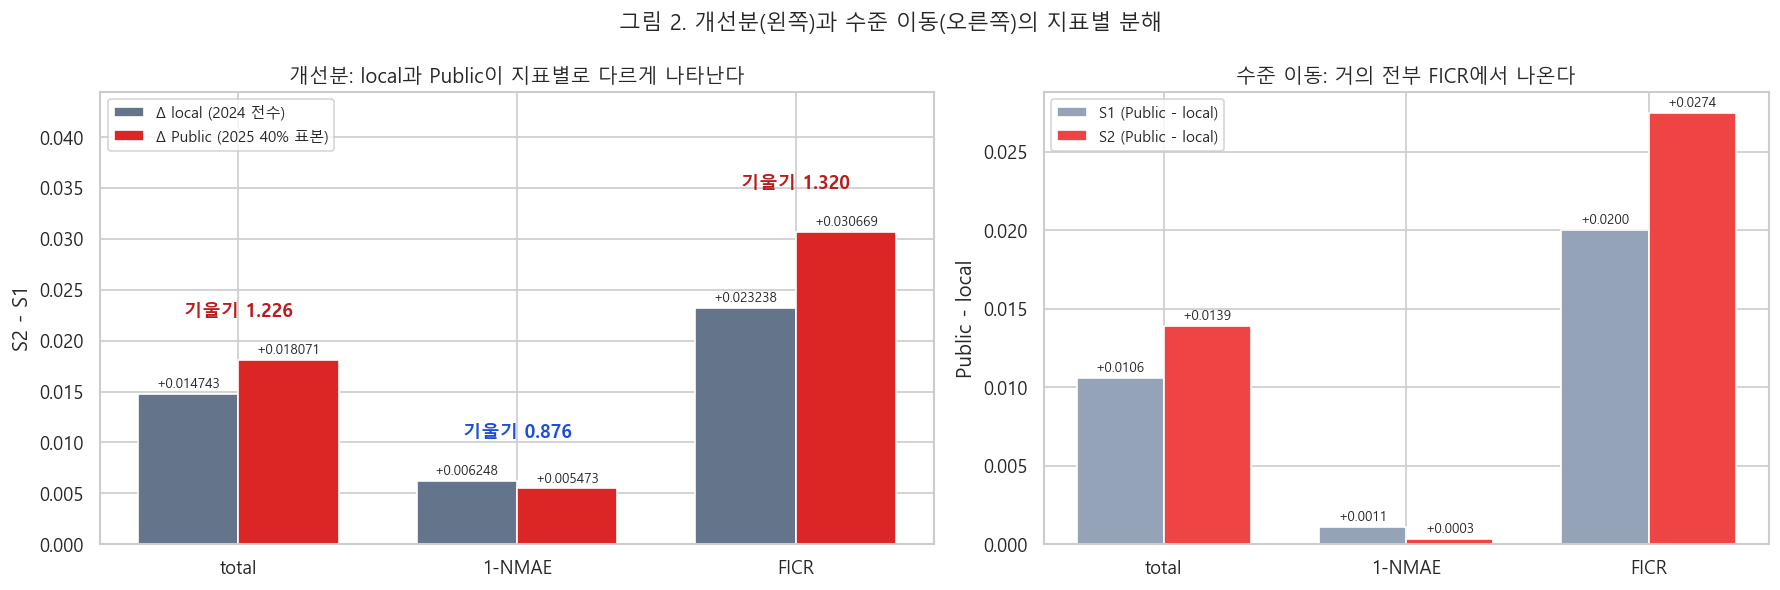

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.15, 1]})
labels = ["total", "1-NMAE", "FICR"]
positions = np.arange(len(labels))
width = 0.36

axis = axes[0]
localBars = axis.bar(
  positions - width / 2, slopeFrame["Δ local"], width, label="Δ local (2024 전수)", color="#64748b"
)
publicBars = axis.bar(
  positions + width / 2, slopeFrame["Δ Public"], width, label="Δ Public (2025 40% 표본)", color="#dc2626"
)
for index, label in enumerate(labels):
  slope = float(slopeFrame.loc[label, "기울기"])
  height = max(float(slopeFrame.loc[label, "Δ local"]), float(slopeFrame.loc[label, "Δ Public"]))
  axis.annotate(
    f"기울기 {slope:.3f}", (index, height), textcoords="offset points", xytext=(0, 26),
    ha="center", fontsize=11, fontweight="bold",
    color="#b91c1c" if slope > 1 else "#1d4ed8",
  )
axis.bar_label(localBars, fmt="%+.6f", padding=2, fontsize=8)
axis.bar_label(publicBars, fmt="%+.6f", padding=2, fontsize=8)
axis.set_xticks(positions, labels)
axis.set_ylabel("S2 - S1")
axis.set_title("개선분: local과 Public이 지표별로 다르게 나타난다", fontsize=12)
axis.set_ylim(0, max(slopeFrame[["Δ local", "Δ Public"]].to_numpy().max() * 1.45, 0.001))
axis.legend(loc="upper left", fontsize=9)

axis = axes[1]
levelS1 = slopeFrame["수준 이동 S1"].to_numpy()
levelS2 = slopeFrame["수준 이동 S2"].to_numpy()
bars1 = axis.bar(positions - width / 2, levelS1, width, label="S1 (Public - local)", color="#94a3b8")
bars2 = axis.bar(positions + width / 2, levelS2, width, label="S2 (Public - local)", color="#ef4444")
axis.bar_label(bars1, fmt="%+.4f", padding=2, fontsize=8)
axis.bar_label(bars2, fmt="%+.4f", padding=2, fontsize=8)
axis.axhline(0, color="#334155", linewidth=1)
axis.set_xticks(positions, labels)
axis.set_ylabel("Public - local")
axis.set_title("수준 이동: 거의 전부 FICR에서 나온다", fontsize=12)
axis.legend(loc="upper left", fontsize=9)

fig.suptitle("그림 2. 개선분(왼쪽)과 수준 이동(오른쪽)의 지표별 분해", fontsize=13)
fig.tight_layout()
plt.show()

### 4-2. 1-NMAE는 감쇠하고 FICR은 증폭한다

| 지표 | Δ local | Δ Public | 기울기 |
|------|---------|----------|--------|
| 1-NMAE | +0.006248 | +0.005473 | **0.876** |
| FICR | +0.023238 | +0.030669 | **1.320** |
| total | +0.014743 | +0.018071 | 1.226 |

총점 기울기 1.226은 이 둘의 평균이다. 즉 "Public이 local보다 개선을 크게 쳐준다"는
말은 **FICR에 한정된 이야기**이며, 평균 오차 자체는 오히려 조금 덜 개선됐다.

오른쪽 패널은 더 분명하다. 수준 이동에서 1-NMAE는 S1 +0.0011, S2 +0.0003으로 사실상
0이고, FICR은 +0.0200, +0.0274다. **2025 평가 구간에서 우리 모델의 평균 오차는 2024와
거의 같은데 정산금 획득률만 크게 올랐다.**

여기까지가 관측이다. 이제 해석을 하기 전에 잡음을 먼저 재야 한다.

---

## 5. Public 40% 표본이 만드는 잡음의 크기

이 절이 이 노트북의 핵심이다.

Public은 평가 데이터의 40% 표본이다. 같은 예측이라도 어떤 40%가 뽑혔느냐에 따라 점수가
달라지고, **두 모델의 차이도 달라진다.** 그 흔들림의 크기를 모르면 기울기 1.226이
의미 있는 값인지 판단할 수 없다.

2025 평가 구간의 실제값을 우리는 모른다. 그래서 조건이 가장 비슷한 2024 holdout에서
같은 실험을 한다 — 8,784행에서 40%를 비복원 추출해 두 모델을 **같은 표본으로** 채점하고,
그 차이의 분포를 본다. 같은 표본을 쓰는 것(paired)이 중요하다. 실제 리더보드도 두 제출을
같은 40%로 채점하기 때문이다.

In [9]:
# 부트스트랩을 4,000회 돌리므로 metric()을 그대로 호출하지 않고 배열로 미리 편다.
actualArrays, validMasks = {}, {}
errorRates = {slot: {} for slot in SLOTS}
for column in TARGET_COLS:
  capacity = CAPACITY_KWH[column]
  actual = holdoutActual[column].to_numpy(dtype=float)
  actualArrays[column] = actual
  validMasks[column] = actual >= capacity * EVALUATION_CAPACITY_RATIO
  for slot in SLOTS:
    predicted = holdoutPredictions[slot][column].to_numpy(dtype=float)
    errorRates[slot][column] = np.abs(predicted - actual) / capacity


def scoreSubset(slot, rowIndex):
  """공식 산식을 행 부분집합에 대해 계산한다. metric()과 같은 필터·단가를 쓴다."""
  groupNmae, groupFicr = [], []
  for column in TARGET_COLS:
    valid = validMasks[column][rowIndex]
    actual = actualArrays[column][rowIndex][valid]
    errorRate = errorRates[slot][column][rowIndex][valid]
    groupNmae.append(errorRate.mean())
    unitPrice = np.select(
      [errorRate <= FICR_UNIT_PRICE[0][0], errorRate <= FICR_UNIT_PRICE[1][0]],
      [FICR_UNIT_PRICE[0][1], FICR_UNIT_PRICE[1][1]],
      default=0.0,
    )
    groupFicr.append((actual * unitPrice).sum() / (actual * 4.0).sum())
  oneMinusNmae = 1 - np.mean(groupNmae)
  ficr = np.mean(groupFicr)
  return 0.5 * oneMinusNmae + 0.5 * ficr


allRows = np.arange(len(holdoutActual))
vectorCheck = scoreSubset("S2", allRows)
print(f"벡터화 산식 검증(S2 전수) : {vectorCheck!r}")
print(f"metric() 결과와 절대 차이 : {abs(vectorCheck - localScores['S2']['total']):.3e}")
print()
print("그룹별 평가 대상 행 수 :", {column: int(validMasks[column].sum()) for column in TARGET_COLS})
print(f"전체 holdout 행 수     : {len(holdoutActual)}")

벡터화 산식 검증(S2 전수) : 0.5924854297224146
metric() 결과와 절대 차이 : 0.000e+00

그룹별 평가 대상 행 수 : {'kpx_group_1': 4989, 'kpx_group_2': 4976, 'kpx_group_3': 4566}
전체 holdout 행 수     : 8784


벡터화한 산식이 `metric()`과 절대 차이 0으로 일치한다. 부트스트랩이 다른 산식을 쓰는
사고를 여기서 막는다.

평가 대상 행이 그룹별로 4,566~4,989행이다. 8,784행 중 절반 정도만 채점된다 —
용량 10% 미만 시간대가 제외되기 때문이다. 40% 표본을 뽑으면 그룹당 1,800~2,000행이
남는다는 뜻이고, 이 정도 표본에서 소수점 셋째 자리를 다투는 셈이다.

In [10]:
BOOTSTRAP_DRAWS = 4000
BOOTSTRAP_SEED = 20260727
subsampleSize = int(round(PUBLIC_SAMPLE_FRACTION * len(allRows)))
generator = np.random.default_rng(BOOTSTRAP_SEED)

drawScores = {slot: np.empty(BOOTSTRAP_DRAWS) for slot in SLOTS}
started = time.perf_counter()
for draw in range(BOOTSTRAP_DRAWS):
  rowIndex = generator.choice(allRows, size=subsampleSize, replace=False)
  for slot in SLOTS:
    drawScores[slot][draw] = scoreSubset(slot, rowIndex)
deltaDraws = drawScores["S2"] - drawScores["S1"]

deltaSd = float(deltaDraws.std(ddof=1))
deltaLow, deltaHigh = np.quantile(deltaDraws, [0.025, 0.975])
observedGap = deltaPublicTotal - deltaLocalTotal
gapInSd = observedGap / deltaSd
tailProbability = float((deltaDraws >= deltaPublicTotal).mean())
slopeInterval = (deltaLow / deltaLocalTotal, deltaHigh / deltaLocalTotal)

print(f"추출 {BOOTSTRAP_DRAWS}회 · 표본 크기 {subsampleSize}행 ({PUBLIC_SAMPLE_FRACTION:.0%}) · {time.perf_counter() - started:.1f}s")
print()
print(f"Δ(S2-S1) 표본분포 평균 : {deltaDraws.mean():+.9f}   (2024 전수 Δlocal {deltaLocalTotal:+.9f})")
print(f"Δ 표준편차             : {deltaSd:.9f}")
print(f"Δ 95% 구간             : [{deltaLow:+.6f}, {deltaHigh:+.6f}]")
print()
print(f"실측 ΔPublic           : {deltaPublicTotal:+.9f}")
print(f"Δlocal과의 차이        : {observedGap:+.9f}  =  {gapInSd:.2f} SD")
print(f"P(Δ_40% >= ΔPublic)    : {tailProbability:.4f}   (양측 {2 * min(tailProbability, 1 - tailProbability):.4f})")
print()
print(f"기울기 점추정          : {slopeTotal:.3f}")
print(f"40% 표본만으로 생기는 기울기 95% 구간 : [{slopeInterval[0]:.3f}, {slopeInterval[1]:.3f}]")
print(f"이 구간이 1.0을 포함하는가 : {slopeInterval[0] <= 1.0 <= slopeInterval[1]}")
print(f"단일 수준 점수의 표준편차 : S1 {drawScores['S1'].std(ddof=1):.6f}, S2 {drawScores['S2'].std(ddof=1):.6f}")

추출 4000회 · 표본 크기 3514행 (40%) · 3.7s

Δ(S2-S1) 표본분포 평균 : +0.014722438   (2024 전수 Δlocal +0.014742862)
Δ 표준편차             : 0.002112472
Δ 95% 구간             : [+0.010558, +0.018850]

실측 ΔPublic           : +0.018071135
Δlocal과의 차이        : +0.003328273  =  1.58 SD
P(Δ_40% >= ΔPublic)    : 0.0535   (양측 0.1070)

기울기 점추정          : 1.226
40% 표본만으로 생기는 기울기 95% 구간 : [0.716, 1.279]
이 구간이 1.0을 포함하는가 : True
단일 수준 점수의 표준편차 : S1 0.003209, S2 0.003264


숫자가 많으니 그림으로 정리한다.

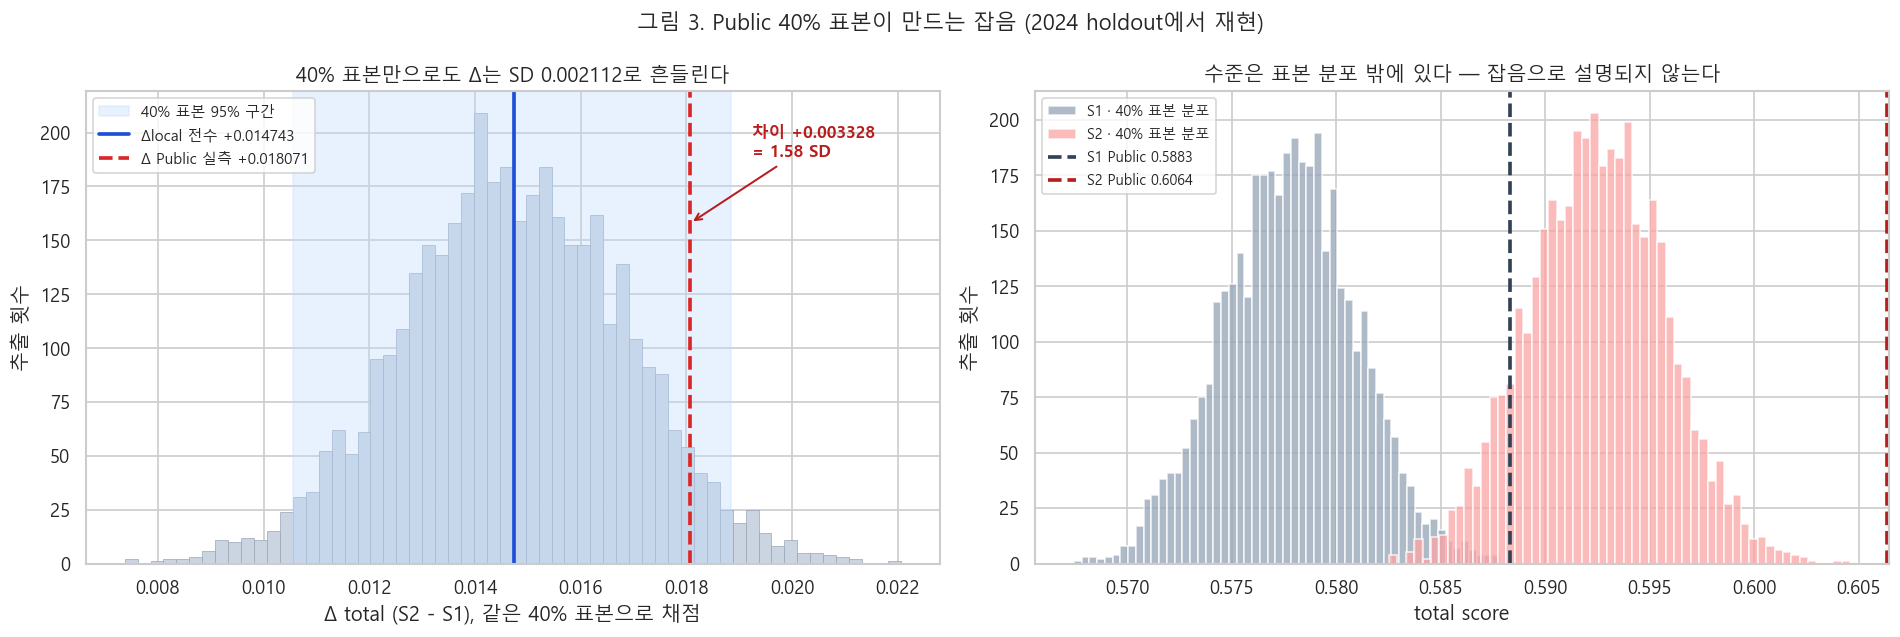

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.4))

axis = axes[0]
axis.hist(deltaDraws, bins=60, color="#cbd5e1", edgecolor="#94a3b8", linewidth=0.4)
axis.axvspan(deltaLow, deltaHigh, color="#bfdbfe", alpha=0.35, label="40% 표본 95% 구간")
axis.axvline(deltaLocalTotal, color="#1d4ed8", linewidth=2.2, label=f"Δlocal 전수 {deltaLocalTotal:+.6f}")
axis.axvline(deltaPublicTotal, color="#dc2626", linewidth=2.2, linestyle="--",
             label=f"Δ Public 실측 {deltaPublicTotal:+.6f}")
axis.annotate(
  f"차이 {observedGap:+.6f}\n= {gapInSd:.2f} SD",
  xy=(deltaPublicTotal, axis.get_ylim()[1] * 0.72),
  xytext=(deltaPublicTotal + deltaSd * 0.55, axis.get_ylim()[1] * 0.86),
  fontsize=10, color="#b91c1c", fontweight="bold",
  arrowprops={"arrowstyle": "->", "color": "#b91c1c", "linewidth": 1.2},
)
axis.set_xlabel("Δ total (S2 - S1), 같은 40% 표본으로 채점")
axis.set_ylabel("추출 횟수")
axis.set_title(f"40% 표본만으로도 Δ는 SD {deltaSd:.6f}로 흔들린다", fontsize=12)
axis.legend(loc="upper left", fontsize=9)

axis = axes[1]
axis.hist(drawScores["S1"], bins=55, color="#94a3b8", alpha=0.75, label="S1 · 40% 표본 분포")
axis.hist(drawScores["S2"], bins=55, color="#fca5a5", alpha=0.75, label="S2 · 40% 표본 분포")
axis.axvline(PUBLIC_RESULTS["S1"]["total"], color="#334155", linewidth=2.2, linestyle="--",
             label=f"S1 Public {PUBLIC_RESULTS['S1']['total']:.4f}")
axis.axvline(PUBLIC_RESULTS["S2"]["total"], color="#b91c1c", linewidth=2.2, linestyle="--",
             label=f"S2 Public {PUBLIC_RESULTS['S2']['total']:.4f}")
axis.set_xlabel("total score")
axis.set_ylabel("추출 횟수")
axis.set_title("수준은 표본 분포 밖에 있다 — 잡음으로 설명되지 않는다", fontsize=12)
axis.legend(loc="upper left", fontsize=8.5)

fig.suptitle("그림 3. Public 40% 표본이 만드는 잡음 (2024 holdout에서 재현)", fontsize=13)
fig.tight_layout()
plt.show()

### 5-1. 기울기 괴리는 잡음 안에 있고, 수준 이동은 밖에 있다

왼쪽 패널이 답이다. 40% 표본만 바뀌어도 Δ는 표준편차 0.0021로 흔들린다.
실측 ΔPublic은 Δlocal보다 0.00333 크지만 이는 **1.58 SD**에 불과하고,
같은 방향으로 이만큼 이상 벌어질 확률이 5.35%다. 관례적 기준 어디에도 못 미친다.

기울기로 환산하면 40% 표본만으로 생기는 95% 구간이 **[0.716, 1.279]**다.
점추정 1.226은 이 구간 안에 있고, **구간은 1.0을 포함한다.**

> 즉 "local이 오르면 Public은 1.23배로 오른다"고 말할 근거가 없다.
> 현재 데이터와 양립하는 기울기는 0.72에서 1.28까지 걸쳐 있다.

오른쪽 패널은 다르다. Public 수준(점선)이 40% 표본 분포에서 한참 벗어나 있다.
S1은 약 3.3 SD, S2는 약 4.3 SD 바깥이다. **수준 이동은 잡음이 아니다.**
다만 이 비교는 2024 표본 분포에 2025 점수를 겹친 것이라 해가 다르다는 점을 감안해야
하며, 표본 분산은 여기서 하한일 뿐이다.

정리하면 설명해야 할 대상이 바뀐다. 기울기가 아니라 **수준 이동**, 그중에서도
**FICR에만 생긴 수준 이동**이다.

### Decision Box ⑯ — 기울기는 점추정이 아니라 구간으로 다룬다

**선택지**

- (A) 기울기 1.226을 환산 계수로 채택하고 이후 local Δ에 곱해 Public을 예측한다
- (B) 기울기를 구간 [0.72, 1.28]로 다루고, 구간이 1.0을 포함하는 동안은 환산에 쓰지 않는다

**근거**

점이 두 개면 직선은 정확히 하나로 정해진다. 자유도가 0이므로 **데이터 자체는 오차를
알려주지 않는다.** 그래서 오차를 밖에서 가져와야 하는데, 대회 안내문이 알려준
"Public = 40% 표본"이 바로 그 출처다. 그 분산을 재 보니 기울기 구간이 1.0을 포함한다.

(A)를 택하면 잡음을 계수로 승격시키는 것이 된다. 이후 모든 후보의 Public 예측이
이 잡음을 물려받고, 특히 후보 간 간격이 작을 때 순위를 뒤집는다.

**채택: (B)** — 기울기는 "아직 1과 구분되지 않는다"가 현재의 결론이다.
구간을 좁히려면 점이 더 필요하고, 점은 제출 횟수를 소모한다.

---

## 6. FICR은 왜 증폭기처럼 행동하는가

기울기의 지표별 분해에서 FICR만 1보다 컸고(1.320), 수준 이동도 FICR에 몰려 있었다.
FICR이 계단 함수이기 때문이라는 것이 설계서 06 5.3절의 가설이다. 행 단위 오차율을
직접 보고 확인한다.

In [12]:
pooledError = {
  slot: np.concatenate([errorRates[slot][column][validMasks[column]] for column in TARGET_COLS])
  for slot in SLOTS
}
tierEdges = [FICR_UNIT_PRICE[0][0], FICR_UNIT_PRICE[1][0]]
tierLabels = ["4원/kWh\n(오차 6% 이하)", "3원/kWh\n(6~8%)", "정산금 없음\n(8% 초과)"]
pooledTier = {slot: np.digitize(pooledError[slot], tierEdges) for slot in SLOTS}

transition = np.zeros((3, 3), dtype=int)
for before, after in zip(pooledTier["S1"], pooledTier["S2"]):
  transition[before, after] += 1

evalRowCount = len(pooledError["S1"])
movedCount = int((pooledTier["S1"] != pooledTier["S2"]).sum())
improvedCount = int((pooledTier["S2"] < pooledTier["S1"]).sum())
worsenedCount = int((pooledTier["S2"] > pooledTier["S1"]).sum())
nearBoundary = float(
  (
    (np.abs(pooledError["S2"] - tierEdges[0]) <= 0.01)
    | (np.abs(pooledError["S2"] - tierEdges[1]) <= 0.01)
  ).mean()
)

tierSummary = pd.DataFrame(
  {
    "S1 행 수": [int((pooledTier["S1"] == t).sum()) for t in range(3)],
    "S2 행 수": [int((pooledTier["S2"] == t).sum()) for t in range(3)],
  },
  index=["4원 구간", "3원 구간", "정산금 없음"],
)
tierSummary["순증감"] = tierSummary["S2 행 수"] - tierSummary["S1 행 수"]

print(f"평가 대상 행 수(3그룹 합) : {evalRowCount}")
print(f"단가 구간이 바뀐 행       : {movedCount} ({movedCount / evalRowCount:.1%})")
print(f"  좋아진 행 {improvedCount} / 나빠진 행 {worsenedCount} → 순증 {improvedCount - worsenedCount}")
print(f"경계(6%·8%) ±1%p 안에 있는 S2 행 : {nearBoundary:.1%}")
print(f"오차율 중앙값 : S1 {np.median(pooledError['S1']):.4f} → S2 {np.median(pooledError['S2']):.4f}")
display(tierSummary)

평가 대상 행 수(3그룹 합) : 14531
단가 구간이 바뀐 행       : 3046 (21.0%)
  좋아진 행 1699 / 나빠진 행 1347 → 순증 352
경계(6%·8%) ±1%p 안에 있는 S2 행 : 18.5%
오차율 중앙값 : S1 0.1099 → S2 0.1049


,S1 행 수,S2 행 수,순증감
4원 구간,4135,4396,261
3원 구간,1328,1330,2
정산금 없음,9068,8805,-263


숫자의 뜻이 그림에서 드러난다. 왼쪽은 오차율이 계단 경계 주변에 얼마나 몰려 있는지,
오른쪽은 S1에서 S2로 갈 때 행들이 구간 사이를 어떻게 이동했는지 보여준다.

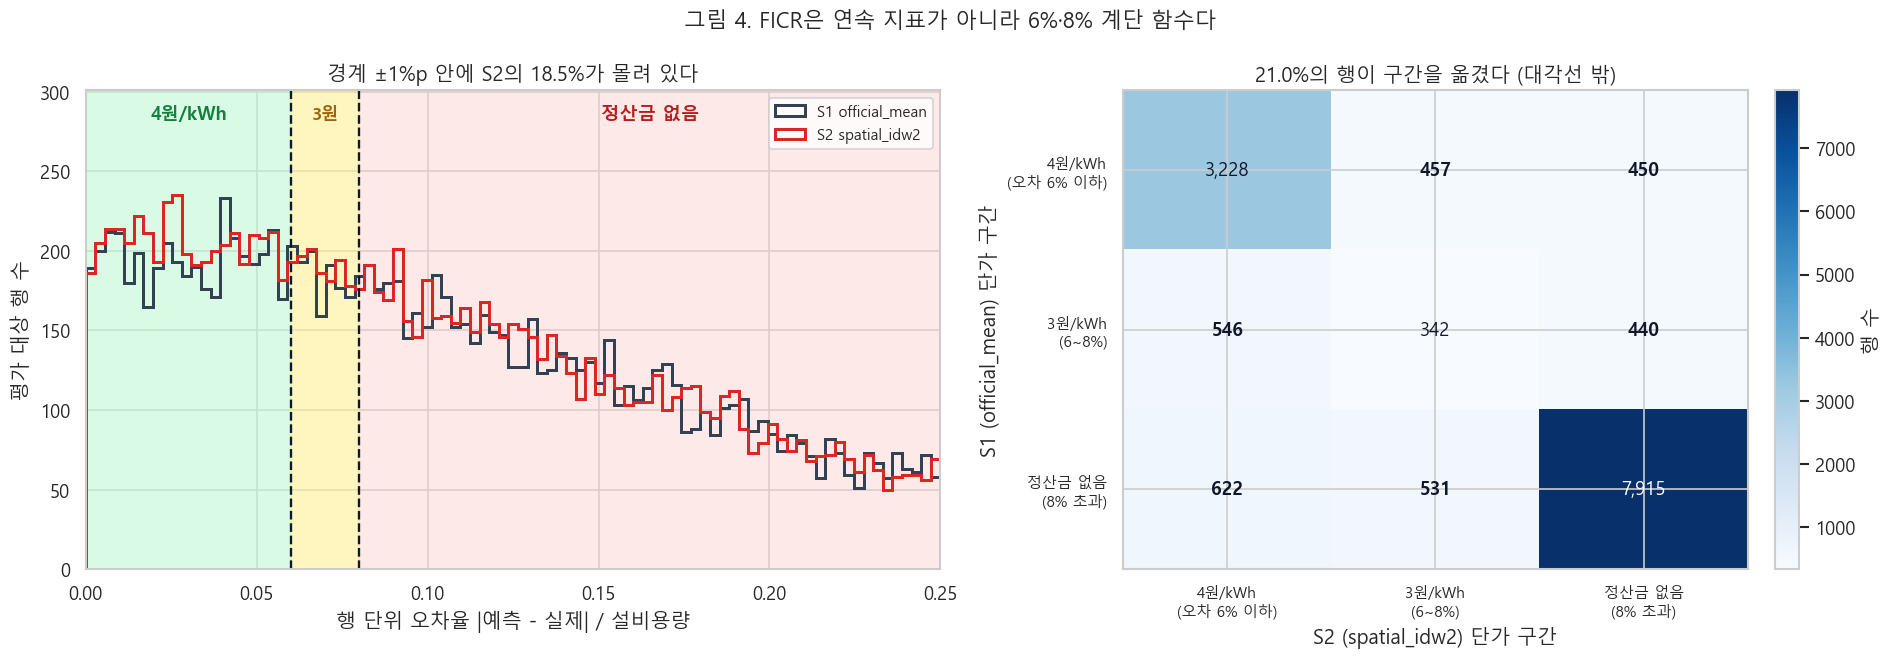

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.6), gridspec_kw={"width_ratios": [1.25, 1]})

axis = axes[0]
bins = np.linspace(0, 0.25, 90)
axis.axvspan(0, tierEdges[0], color="#bbf7d0", alpha=0.55)
axis.axvspan(tierEdges[0], tierEdges[1], color="#fef08a", alpha=0.55)
axis.axvspan(tierEdges[1], 0.25, color="#fecaca", alpha=0.40)
axis.hist(pooledError["S1"], bins=bins, histtype="step", linewidth=1.8, color="#334155", label="S1 official_mean")
axis.hist(pooledError["S2"], bins=bins, histtype="step", linewidth=1.8, color="#dc2626", label="S2 spatial_idw2")
for edge in tierEdges:
  axis.axvline(edge, color="#0f172a", linewidth=1.4, linestyle="--")
# 단가 구간 이름을 히스토그램 위쪽 여백에 놓는다. 여백이 없으면 막대와 겹친다.
axis.set_ylim(0, axis.get_ylim()[1] * 1.22)
labelHeight = axis.get_ylim()[1] * 0.94
axis.text(0.030, labelHeight, "4원/kWh", ha="center", fontsize=11, fontweight="bold", color="#15803d")
axis.text(0.070, labelHeight, "3원", ha="center", fontsize=10.5, fontweight="bold", color="#a16207")
axis.text(0.165, labelHeight, "정산금 없음", ha="center", fontsize=11, fontweight="bold", color="#b91c1c")
axis.set_xlabel("행 단위 오차율 |예측 - 실제| / 설비용량")
axis.set_ylabel("평가 대상 행 수")
axis.set_title(f"경계 ±1%p 안에 S2의 {nearBoundary:.1%}가 몰려 있다", fontsize=12)
axis.set_xlim(0, 0.25)
axis.legend(loc="upper right", fontsize=9)

axis = axes[1]
image = axis.imshow(transition, cmap="Blues", aspect="auto")
axis.set_xticks(range(3), tierLabels, fontsize=9)
axis.set_yticks(range(3), tierLabels, fontsize=9)
axis.set_xlabel("S2 (spatial_idw2) 단가 구간")
axis.set_ylabel("S1 (official_mean) 단가 구간")
threshold = transition.max() * 0.55
for row in range(3):
  for column in range(3):
    axis.text(
      column, row, f"{transition[row, column]:,}",
      ha="center", va="center", fontsize=11,
      color="white" if transition[row, column] > threshold else "#0f172a",
      fontweight="bold" if row != column else "normal",
    )
axis.set_title(f"{movedCount / evalRowCount:.1%}의 행이 구간을 옮겼다 (대각선 밖)", fontsize=12)
fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04, label="행 수")

fig.suptitle("그림 4. FICR은 연속 지표가 아니라 6%·8% 계단 함수다", fontsize=13)
fig.tight_layout()
plt.show()

### 6-1. 작은 예측 변화가 큰 FICR 변화를 만드는 구조

세 가지가 함께 읽힌다.

1. **경계 근처 밀도가 높다.** S2 평가 행의 18.5%가 6% 또는 8% 경계에서 ±1%p 안에 있다.
   예측이 조금만 움직여도 이 행들의 단가가 4원↔3원↔0원으로 계단을 오르내린다.
2. **실제로 대량 이동이 일어났다.** S1 대비 S2에서 **21.0%의 행이 단가 구간을 옮겼다.**
   좋아진 행 1,699개, 나빠진 행 1,347개로 순증은 352개뿐이다. 개선분의 몸통은
   **순증 352개**이지만 그 아래에서 3,046개가 오르내렸다.
3. **평균 오차 변화는 작다.** 오차율 중앙값은 0.1099에서 0.1049로 0.005 줄었을 뿐이다.

즉 FICR은 예측 개선을 **증폭해서 반영하는 동시에 잡음도 증폭한다.** 순증 352가 전체
이동 3,046의 11.6%밖에 안 된다는 것은, 표본이 바뀌면 이 순증이 쉽게 달라질 수 있다는 뜻이다.
5절에서 잰 Δ의 표준편차 0.0021이 바로 이 구조에서 나온다.

이것으로 두 가지가 설명된다 — 기울기에서 FICR만 1을 넘은 것도, 수준 이동이 FICR에만
생긴 것도, 모두 이 계단 구조의 결과다.

---

## 7. 2025 결측 조건은 점수를 끌어내렸는가

설계서 06 5.3절의 첫 번째 이유다. 2025 test는 550개 컬럼 중 133개에 결측이 있고
train median으로 채워진다. 2024 holdout에는 그런 결측이 없다. 이 조건 차이가 Public
점수를 끌어내렸는지 확인한다.

In [14]:
submissionFrames = {
  slot: pd.read_csv(outputRoot / "submissions" / PUBLIC_RESULTS[slot]["file"], encoding="utf-8-sig")
  for slot in SLOTS
}

distributionRows = []
for slot in SLOTS:
  for column in TARGET_COLS:
    holdoutSeries = holdoutPredictions[slot][column]
    submitSeries = submissionFrames[slot][column]
    distributionRows.append(
      {
        "slot": slot,
        "group": column,
        "holdout 평균": holdoutSeries.mean(),
        "제출 평균": submitSeries.mean(),
        "평균 비": submitSeries.mean() / holdoutSeries.mean(),
        "holdout 표준편차": holdoutSeries.std(),
        "제출 표준편차": submitSeries.std(),
        "제출 최솟값": submitSeries.min(),
        "제출 최댓값": submitSeries.max(),
      }
    )
distributionFrame = pd.DataFrame(distributionRows).set_index(["slot", "group"])

pairedS1 = np.concatenate([submissionFrames["S1"][column].to_numpy() for column in TARGET_COLS])
pairedS2 = np.concatenate([submissionFrames["S2"][column].to_numpy() for column in TARGET_COLS])
submissionCorrelation = float(np.corrcoef(pairedS1, pairedS2)[0, 1])
submissionMeanAbsDiff = float(np.mean(np.abs(pairedS1 - pairedS2)))

print(f"제출물 두 벌의 상관계수   : {submissionCorrelation:.4f}")
print(f"제출물 두 벌의 평균 절대차 : {submissionMeanAbsDiff:.1f} kWh")
print(f"제출 행 수                : {len(submissionFrames['S1'])} (양쪽 동일: {len(submissionFrames['S1']) == len(submissionFrames['S2'])})")
display(distributionFrame)

제출물 두 벌의 상관계수   : 0.9912
제출물 두 벌의 평균 절대차 : 541.1 kWh
제출 행 수                : 8760 (양쪽 동일: True)


holdout 평균       제출 평균     평균 비  holdout 표준편차     제출 표준편차     제출 최솟값       제출 최댓값
slot group                                                                                         
S1   kpx_group_1 6172.440766 7359.033109 1.192240   5439.323290 5522.402178 245.593563 18794.431599
     kpx_group_2 6754.866242 7875.371758 1.165881   5977.296259 5899.754313 290.611156 19875.574073
     kpx_group_3 5242.138093 6335.105336 1.208496   4900.153353 5195.564420 202.026338 18051.305516
S2   kpx_group_1 6187.129097 7382.550549 1.193211   5544.336342 5624.899431 186.174873 19800.674754
     kpx_group_2 6769.253228 7891.992502 1.165859   6092.029846 6015.879732 193.832759 20226.756283
     kpx_group_3 5288.145074 6323.576805 1.195802   5051.221368 5318.592176 140.698877 18415.587261

표만으로는 분포 모양을 알 수 없다. 겹쳐 그린다.

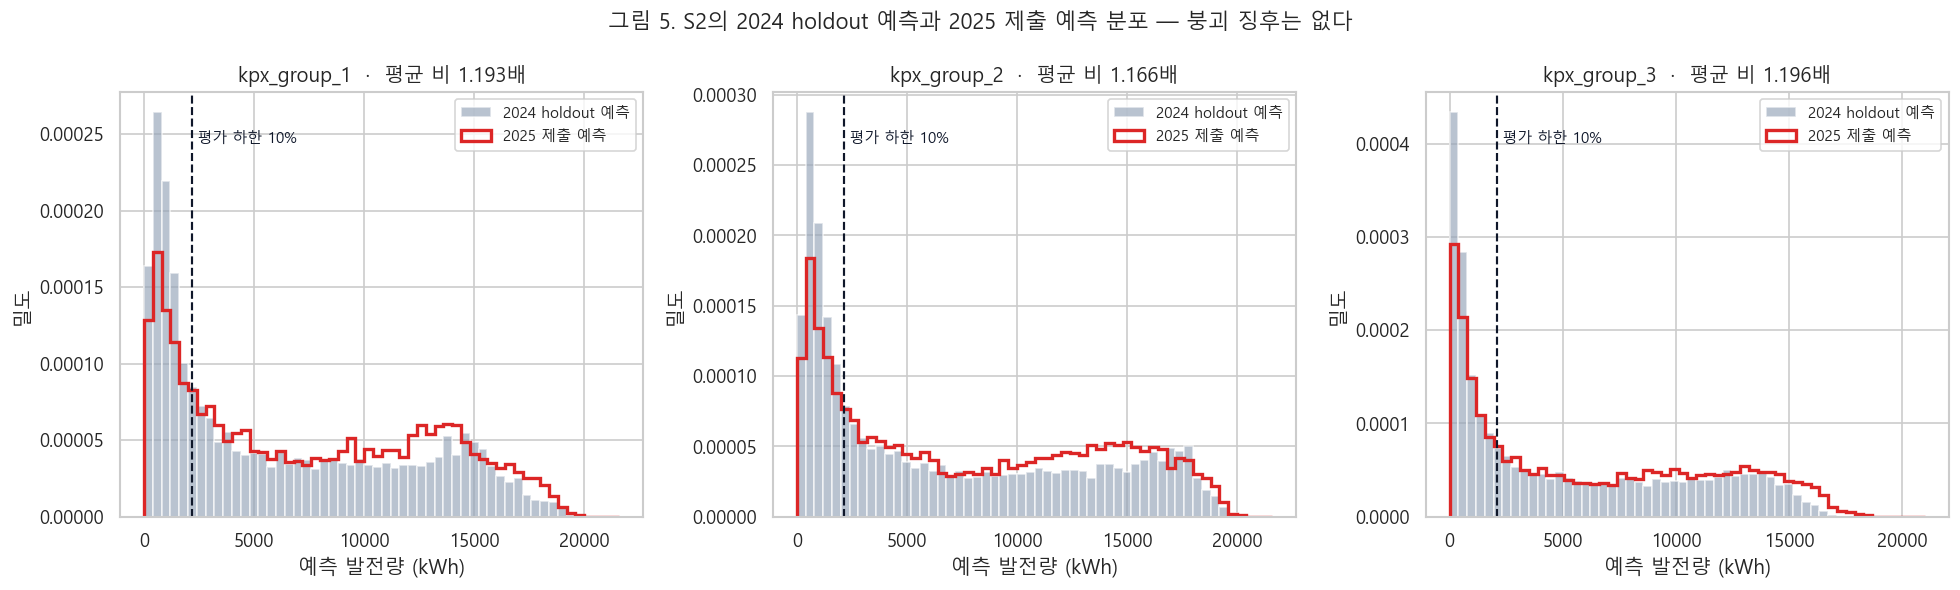

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))
for axis, column in zip(axes, TARGET_COLS):
  capacity = CAPACITY_KWH[column]
  bins = np.linspace(0, capacity, 55)
  axis.hist(
    holdoutPredictions["S2"][column], bins=bins, density=True,
    color="#94a3b8", alpha=0.65, label="2024 holdout 예측",
  )
  axis.hist(
    submissionFrames["S2"][column], bins=bins, density=True,
    histtype="step", linewidth=2.0, color="#dc2626", label="2025 제출 예측",
  )
  axis.axvline(capacity * EVALUATION_CAPACITY_RATIO, color="#0f172a", linestyle="--", linewidth=1.3)
  axis.text(
    capacity * EVALUATION_CAPACITY_RATIO, axis.get_ylim()[1] * 0.88, " 평가 하한 10%",
    fontsize=9, color="#0f172a",
  )
  ratio = float(submissionFrames["S2"][column].mean() / holdoutPredictions["S2"][column].mean())
  axis.set_title(f"{column}  ·  평균 비 {ratio:.3f}배", fontsize=12)
  axis.set_xlabel("예측 발전량 (kWh)")
  axis.set_ylabel("밀도")
  axis.legend(loc="upper right", fontsize=9)

fig.suptitle("그림 5. S2의 2024 holdout 예측과 2025 제출 예측 분포 — 붕괴 징후는 없다", fontsize=13)
fig.tight_layout()
plt.show()

### 7-1. 결측 대치는 예측을 무너뜨리지 않았다

2025 제출 예측의 분포가 2024 holdout 예측과 같은 모양이며, 평균이 1.19~1.21배
높은 쪽으로 평행 이동해 있다. 결측 133컬럼을 train median으로 채운 결과가
**상수로 눌린 예측**이나 **분산이 죽은 예측**으로 나타났다면 여기서 보였을 텐데,
그런 징후는 없다.

더 결정적인 것은 점수의 방향이다. 결측 대치가 Public을 끌어내렸다면 Public이 local보다
**낮아야** 한다. 실제로는 S1 +0.0106, S2 +0.0139로 둘 다 **높다.** 이 이유는 관측된
수준 이동의 방향과 반대이므로, 적어도 주된 원인은 아니다.

다만 "해롭지 않았다"까지만 말할 수 있다. 결측이 없었다면 더 높았을 가능성은 이 데이터로
배제되지 않으며, 2024에 대응 조건이 없으므로 크기를 잴 방법도 없다.

---

## 8. 원인 판별

설계서 06 5.3절이 적어 둔 세 가지 이유에, 규칙에서 새로 확인한 네 번째를 더해 판정한다.
판별 방법은 하나다 — **각 이유가 예측하는 방향과 실측 방향이 맞는가.**

In [16]:
verdictRows = [
  {
    "이유": "Public 40% 표본 분산",
    "예측하는 현상": "Δ가 SD 0.0021로 흔들린다",
    "실측": f"Δ 괴리 {observedGap:+.6f} = {gapInSd:.2f} SD (P={tailProbability:.3f})",
    "판정": "기울기 괴리를 단독으로 설명한다",
  },
  {
    "이유": "FICR 계단 함수",
    "예측하는 현상": "수준 이동이 FICR에 몰린다",
    "실측": f"1-NMAE {slopeFrame.loc['1-NMAE', '수준 이동 S2']:+.4f} / FICR {slopeFrame.loc['FICR', '수준 이동 S2']:+.4f}",
    "판정": "수준 이동의 주 원인",
  },
  {
    "이유": "학습 구간 차이(2022~2024)",
    "예측하는 현상": "1-NMAE와 FICR이 함께 오른다",
    "실측": f"1-NMAE 수준 이동이 S1 {slopeFrame.loc['1-NMAE', '수준 이동 S1']:+.4f}, S2 {slopeFrame.loc['1-NMAE', '수준 이동 S2']:+.4f}로 거의 0",
    "판정": "기여가 보이지 않는다 — 주 원인 아님",
  },
  {
    "이유": "2025 결측 133컬럼",
    "예측하는 현상": "Public이 local보다 낮아진다",
    "실측": f"Public - local이 S1 {slopeFrame.loc['total', '수준 이동 S1']:+.4f}, S2 {slopeFrame.loc['total', '수준 이동 S2']:+.4f}로 둘 다 양수",
    "판정": "방향이 반대 — 주 원인 아님",
  },
]
verdictFrame = pd.DataFrame(verdictRows).set_index("이유")
display(verdictFrame)

print("남은 설명 후보 : 2025 평가 구간 자체가 2024보다 정산 구간에 들어가기 쉬운 해였을 가능성")
print("이 가설은 2025 실제값을 모르므로 이번 데이터로는 검증할 수 없다.")

,예측하는 현상,실측,판정
이유,,,
Public 40% 표본 분산,Δ가 SD 0.0021로 흔들린다,Δ 괴리 +0.003328 = 1.58 SD (P=0.053),기울기 괴리를 단독으로 설명한다
FICR 계단 함수,수준 이동이 FICR에 몰린다,1-NMAE +0.0003 / FICR +0.0274,수준 이동의 주 원인
학습 구간 차이(2022~2024),1-NMAE와 FICR이 함께 오른다,"1-NMAE 수준 이동이 S1 +0.0011, S2 +0.0003로 거의 0",기여가 보이지 않는다 — 주 원인 아님
2025 결측 133컬럼,Public이 local보다 낮아진다,"Public - local이 S1 +0.0106, S2 +0.0139로 둘 다 양수",방향이 반대 — 주 원인 아님


남은 설명 후보 : 2025 평가 구간 자체가 2024보다 정산 구간에 들어가기 쉬운 해였을 가능성
이 가설은 2025 실제값을 모르므로 이번 데이터로는 검증할 수 없다.


### 8-1. 결론 — 설명해야 할 것은 기울기가 아니었다

작업 지시는 "괴리가 있으면 원인 세 가지 중 어느 것인지 판별"이었다. 판별 결과는
질문의 전제를 한 칸 옮긴다.

**기울기에는 판별할 괴리가 없다.** 1.226은 40% 표본 잡음이 만드는 [0.72, 1.28] 안에 있다.
세 가지 이유를 동원할 필요가 없으며, 동원하면 잡음에 이야기를 붙이는 것이 된다.

**대신 수준 이동이 있고, 그것은 잡음이 아니다.** 그리고 그 수준 이동은 거의 전부
FICR에서 왔다(1-NMAE는 +0.0003~+0.0011로 사실상 0). 세 이유 중 **FICR 계단 함수**만이
이 패턴을 예측하며, 나머지 둘은 방향이 맞지 않거나 흔적이 없다.

남는 해석은 2025 평가 구간이 2024보다 정산 구간에 들어가기 쉬운 해였을 가능성인데,
실제값이 없으므로 검증할 수 없다. **검증할 수 없다는 사실을 적어 두는 것**이 여기서
할 수 있는 최선이다.

### Decision Box ⑰ — 최종 채점 파일을 리더보드 자동 선택에 맡기지 않는다

**선택지**

- (A) 그대로 둔다. 규칙상 Public 순위가 가장 높은 파일이 자동 선택된다
- (B) 최종 채점 파일을 명시적으로 선택하고, 그 선택 기준을 Public 점수에 두지 않는다

**근거**

대회 안내문은 "파일 제출 시마다 순위가 가장 높은 파일이 자동으로 선택됨"이라고 적고,
동시에 1차 평가는 **Private Score 100%**라고 적는다. Public은 40%, Private은 나머지
60%다. 자동 선택은 40% 표본 최고점을 고르는 규칙이며, 이는 Blum과 Hardt가 리더보드
과적합으로 정리한 구조 그 자체다.

5절에서 잰 값이 이 위험의 크기를 준다. 단일 제출의 40% 표본 표준편차가 약 0.0032다.
Public 점수가 이만큼 흔들린다면, 실력 차이가 그보다 작은 두 후보 사이에서 자동 선택은
사실상 동전 던지기다. 현재 후보 간 최소 간격은 0.00056으로 이 값의 **0.18배**에 불과하다.

**채택: (B)** — 지금은 S2가 Public 최고점이자 local 최고점이라 자동 선택과 결과가
같지만, 이는 우연이다. 앞으로 후보가 늘면 두 기준이 갈라진다. ledger의 `selected`
칸에 사람이 고른 파일을 기록하고, 그 근거를 local fold 성적에 둔다.

---

## 9. ledger와 run registry에 반입

Public 점수가 돌아왔으니 노트북 11이 비워 둔 칸을 채운다. registry는
`RUN_REGISTRY_COLUMNS` schema가 고정돼 있으므로 컬럼을 추가하지 않고
`update_run_registry_submission()`을 통해 값만 채운다.

In [17]:
from baram.registry import RUN_REGISTRY_COLUMNS, update_run_registry_submission

registryPath = outputRoot / "run_registry.csv"
ledgerPath = outputRoot / "submission_ledger_draft.csv"

registryBefore = pd.read_csv(registryPath, encoding="utf-8-sig")
runIdBySlot = {}
for slot, featureSetName in SLOTS.items():
  match = registryBefore["submission_filename"].astype(str).str.endswith(PUBLIC_RESULTS[slot]["file"])
  if int(match.sum()) != 1:
    raise ValueError(f"{slot} 제출 파일에 대응하는 run이 유일하지 않습니다")
  runIdBySlot[slot] = str(registryBefore.loc[match, "run_id"].iloc[0])

for slot, runId in runIdBySlot.items():
  row = registryBefore.loc[registryBefore["run_id"].astype(str) == runId].iloc[0]
  update_run_registry_submission(
    registryPath,
    run_id=runId,
    # 제출물 자체는 바뀌지 않았다. 기존 값을 그대로 되돌려 넣고 Public 결과만 추가한다.
    submission_filename=row["submission_filename"],
    submission_sha256=row["submission_sha256"],
    submission_rows=int(row["submission_rows"]),
    submission_encoding=row["submission_encoding"],
    public_score=PUBLIC_RESULTS[slot]["total"],
    dacon_submission_id=PUBLIC_RESULTS[slot]["dacon_submission_id"],
    selected=PUBLIC_RESULTS[slot]["selected"],
  )

registryAfter = pd.read_csv(registryPath, encoding="utf-8-sig")
schemaIntact = list(registryAfter.columns) == RUN_REGISTRY_COLUMNS
print(f"registry schema 유지 : {schemaIntact}  (컬럼 {len(registryAfter.columns)}개)")
print(f"행 수 변화           : {len(registryBefore)} -> {len(registryAfter)}")
display(
  registryAfter.set_index("experiment_id")[
    ["total_score", "public_score", "dacon_submission_id", "selected", "status"]
  ]
)

registry schema 유지 : True  (컬럼 37개)
행 수 변화           : 2 -> 2


,total_score,public_score,dacon_submission_id,selected,status
experiment_id,,,,,
s1_official_mean_smoke,0.577743,0.588303,1502789.000000,False,submission_validated
s2_spatial_idw2_all_group,0.592485,0.606374,1502791.000000,True,submission_validated


registry는 schema를 그대로 유지한 채 세 칸만 채워졌다. 이제 사람이 읽는 ledger를 갱신한다.
Public 점수는 총점만이 아니라 1-NMAE와 FICR로도 돌아왔으므로, 이 노트북의 분석 근거가
된 두 값도 함께 남긴다.

In [18]:
ledger = pd.read_csv(ledgerPath, encoding="utf-8-sig").set_index("slot")


def fillFromPublic(field, default=None):
  """행 단위 대입은 비어 있던 float 컬럼과 dtype이 충돌한다. 컬럼 통째로 넣는다."""
  return [
    PUBLIC_RESULTS[slot][field] if field in PUBLIC_RESULTS[slot] else default
    for slot in ledger.index
  ]


ledger["public_score"] = fillFromPublic("total")
ledger["dacon_submission_id"] = fillFromPublic("dacon_submission_id")
ledger["public_one_minus_nmae"] = fillFromPublic("one_minus_nmae")
ledger["public_ficr"] = fillFromPublic("ficr")
ledger["제출 시각 KST"] = fillFromPublic("submitted_at_kst")
ledger["최종 채점 선택"] = fillFromPublic("selected")
ledger["public 기준"] = f"2025 평가 {PUBLIC_SAMPLE_FRACTION:.0%} 표본 · 2022~2024 학습 모델"

ledger["local↔Public 차이"] = ledger["public_score"] - ledger["local holdout total"]
ledger.to_csv(ledgerPath, encoding="utf-8-sig")

print(f"ledger 갱신 : {ledgerPath.name}")
print(f"빈 칸이 남아 있는가 : {bool(ledger[['public_score', 'dacon_submission_id']].isna().to_numpy().any())}")
display(
  ledger[
    [
      "feature_set", "local holdout total", "public_score", "local↔Public 차이",
      "public_one_minus_nmae", "public_ficr", "dacon_submission_id", "최종 채점 선택",
    ]
  ].T
)

ledger 갱신 : submission_ledger_draft.csv
빈 칸이 남아 있는가 : False


slot,S1,S2
feature_set,official_mean,spatial_idw2_all_group
local holdout total,0.577743,0.592485
public_score,0.588303,0.606374
local↔Public 차이,0.010560,0.013889
public_one_minus_nmae,0.864425,0.869899
public_ficr,0.312180,0.342849
dacon_submission_id,1502789,1502791
최종 채점 선택,False,True


### 9-1. ledger가 닫혔다

`public_score`와 `dacon_submission_id`가 채워졌고, 이 노트북의 분석이 쓴 Public 1-NMAE와
FICR도 함께 기록됐다. `최종 채점 선택` 칸이 Decision Box ⑰의 결정을 담는다.

`local↔Public 차이` 칸을 새로 두었다. 앞으로 제출이 쌓이면 이 열이 곧 캘리브레이션
이력이 되며, 점이 늘어날수록 5절의 구간이 좁아진다.

### Decision Box ⑱ — 후보 순위는 "간격 > 잡음"일 때만 확정한다

**선택지**

- (A) 지금까지처럼 2024 holdout total 한 숫자로 후보 순위를 정한다
- (B) 후보 간 간격을 측정된 잡음과 비교하고, 간격이 잡음보다 작으면 순위를 확정하지 않는다

**근거**

5절에서 두 개의 잡음 크기를 얻었다.

| 잡음 | 표준편차 |
|------|----------|
| Public 단일 점수 (40% 표본) | 약 0.0032 |
| Public 두 제출의 차이 (같은 표본, paired) | 약 0.0021 |

현재 후보 간 최소 간격은 **0.00056**(nearest_own 0.589828 ↔ idw_p2_own 0.589269)으로,
paired 잡음의 **0.27배**다. 이 간격은 Public 한 점으로도, 2024 단일 holdout으로도
확정할 수 없다. 채택 후보와 통제군의 간격 0.014743은 잡음의 7배라 안전하지만,
GBM·calibration으로 후보가 수십 개가 되면 대부분이 위험 구간에 들어온다.

**채택: (B)** — 다음 작업(F1~F4 seasonal·time fold)의 목적을 "점수를 올리는 것"이 아니라
**fold 간 분산을 재서 순위 확정의 문턱을 정하는 것**으로 둔다. 제출 슬롯은 잡음 확인에
쓰지 않는다. 오늘 2회를 썼고 3회가 남았지만, 남은 슬롯으로 같은 크기의 차이를 다시
재 봐야 정보가 늘지 않는다.

---

## 10. 종합 결론

### 10-1. 연구 질문

> local holdout에서 잰 개선분 +0.014743이 Public에서도 같은 크기로 나타나는가?

**나타났다. 그리고 다르게 나타났다고 말할 근거는 없다.**
ΔPublic +0.018071은 Δlocal보다 크지만, 그 차이는 40% 표본 잡음의 1.58 SD로
같은 방향의 우연이 5.35% 확률로 만들어 내는 크기다.

### 10-2. 단계별 요약

| 절 | 확인한 것 | 결과 |
|----|-----------|------|
| 1 | 규칙 반입 | Public = 40% 표본이라는 사실이 분석 방법을 바꿨다 |
| 2 | 점수 전사 | 공식 산식 항등식으로 검증 통과 |
| 3 | local 재계산 | 노트북 08 전체 정밀도와 절대 차이 0.0 |
| 4 | 기울기 | total 1.226 = 1-NMAE 0.876과 FICR 1.320의 합성 |
| 5 | 잡음 측정 | paired Δ의 SD 0.0021, 기울기 95% 구간 [0.72, 1.28] |
| 6 | FICR 구조 | 평가 행의 21.0%가 단가 구간을 이동, 순증은 그중 11.6% |
| 7 | 결측 조건 | 예측 분포 붕괴 없음, 점수 방향도 반대 |
| 8 | 원인 판별 | 기울기 괴리는 잡음, 수준 이동은 FICR 계단 |
| 9 | 반입 | ledger·registry의 빈 칸이 채워짐 |

### 10-3. 주요 발견

1. **점 두 개로 기울기를 말하려면 오차를 밖에서 가져와야 한다.** 두 점을 지나는 직선은
   자유도가 0이라 데이터 자체가 불확실성을 알려주지 않는다. 대회 안내문의
   "Public = 사전 샘플링된 40%"가 그 출처였고, 이 한 문장이 결론을 뒤집었다.
   규칙 문서를 데이터 문서로 읽어야 하는 사례다.
2. **개선분과 수준 이동은 다른 현상이고 원인도 다르다.** 개선분 차이는 잡음이었지만
   수준 이동은 잡음이 아니었고, 지표별로 쪼개니 전부 FICR에 몰려 있었다.
   총점 하나만 봤다면 "Public이 후하다"로 끝났을 것이다.
3. **FICR은 신호와 잡음을 함께 증폭한다.** 21.0%의 행이 단가 구간을 오갔지만 순증은
   11.6%에 불과했다. 이 낮은 순증 비율이 Δ 표준편차 0.0021의 근원이며,
   후보 간 간격이 작을수록 FICR 기반 순위는 불안정해진다.

### 10-4. 한계

- **잡음을 2024로 대신 쟀다.** 2025 평가 구간의 실제값이 없으므로 40% 표본 분산을
  2024 holdout에서 측정했다. 2025의 분산이 이와 같다는 보장은 없다.
- **수준 이동의 원인은 배제만 했다.** FICR 계단이 남았다는 것은 나머지 둘이 방향이
  맞지 않는다는 소거법의 결과이며, 2025가 실제로 어떤 해였는지는 확인할 수 없다.
- **Private은 여전히 보이지 않는다.** 우리가 본 것은 40%이고 1차 평가는 나머지 60%다.
  이 노트북의 어떤 결론도 Private 점수의 예측이 아니다.
- **모델은 하나도 바꾸지 않았다.** RandomForest 공식 파라미터 그대로다.

### 10-5. 요약

Public 두 점을 반입해 ledger를 닫았고, 기울기 1.226이 40% 표본 잡음과 구분되지 않는다는
것을 4,000회 부트스트랩으로 보였다. 설명이 필요한 대상은 기울기가 아니라 FICR에만 생긴
수준 이동이며, 후보 순위를 확정하려면 간격이 잡음(paired SD 0.0021)을 넘어야 한다는
문턱을 얻었다. 다음 작업인 seasonal·time fold의 목적은 이 문턱을 fold 분산으로
다시 재는 것이다.

---

## 산출물 확인

In [19]:
touchedFiles = [ledgerPath, registryPath]
print("이 노트북이 갱신한 파일:")
for path in touchedFiles:
  print(f"  - {path.relative_to(outputRoot.parent)}  ({path.stat().st_size:,} bytes)")

print()
print("gitignore 대상 경로인가 :", "outputs/**" in (projectRoot / ".gitignore").read_text(encoding="utf-8"))
print("원자료 수정 여부        :", ldapsTrain.shape == (420864, 35))
print("holdout 실제값 SHA-256 불변 :", hashlib.sha256(
  pd.util.hash_pandas_object(holdoutActual, index=True).to_numpy().tobytes()
).hexdigest() == actualFingerprint)
print("제출 CSV 무수정 확인    :", all(
  len(submissionFrames[slot]) == 8760 for slot in SLOTS
))

이 노트북이 갱신한 파일:
  - outputs\submission_ledger_draft.csv  (1,511 bytes)
  - outputs\run_registry.csv  (3,190 bytes)

gitignore 대상 경로인가 : True
원자료 수정 여부        : True
holdout 실제값 SHA-256 불변 : True
제출 CSV 무수정 확인    : True


ledger와 run registry만 갱신됐고 두 파일 모두 `outputs/` 아래라 커밋되지 않는다.
공식 원자료와 holdout 실제값은 읽기만 했으며 제출 CSV도 건드리지 않았다.

다음 단계는 설계서 05의 12절 P1(F1~F4 seasonal·time fold)이다. 이 노트북이 남긴
문턱 — **paired 잡음 SD 0.0021** — 이 그 작업에서 fold 간 분산과 비교될 기준선이다.